Predicting the house price based on the previous house prices

Importing all the required Frameworks for the model

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [8]:
df = pd.read_csv('../csv/House Price India.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

In [10]:
df.columns

Index(['id', 'Date', 'number of bedrooms', 'number of bathrooms',
       'living area', 'lot area', 'number of floors', 'waterfront present',
       'number of views', 'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Renovation Year', 'Postal Code', 'Lattitude',
       'Longitude', 'living_area_renov', 'lot_area_renov',
       'Number of schools nearby', 'Distance from the airport', 'Price'],
      dtype='object')

In [11]:
df.drop(['id','Date','number of views','Lattitude','Longitude','Number of schools nearby','Distance from the airport','waterfront present'],axis=1,inplace=True)


In [12]:
df.dropna()

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Postal Code,living_area_renov,lot_area_renov,Price
0,5,2.50,3650,9050,2.0,5,10,3370,280,1921,0,122003,2880,5400,2380000
1,4,2.50,2920,4000,1.5,5,8,1910,1010,1909,0,122004,2470,4000,1400000
2,5,2.75,2910,9480,1.5,3,8,2910,0,1939,0,122004,2940,6600,1200000
3,4,2.50,3310,42998,2.0,3,9,3310,0,2001,0,122005,3350,42847,838000
4,3,2.00,2710,4500,1.5,4,8,1880,830,1929,0,122006,2060,4500,805000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,2,1.50,1556,20000,1.0,4,7,1556,0,1957,0,122066,2250,17286,221700
14616,3,2.00,1680,7000,1.5,4,7,1680,0,1968,0,122072,1540,7480,219200
14617,2,1.00,1070,6120,1.0,3,6,1070,0,1962,0,122056,1130,6120,209000
14618,4,1.00,1030,6621,1.0,4,6,1030,0,1955,0,122042,1420,6631,205000


Just finding how many houses are renovated to decide if i have to use it or drop it

In [13]:
renovated_houses = df[df['Renovation Year'] > 0 ]
print(len(renovated_houses))

666


In [21]:
df['age of house'] = 2025 - df['Built Year']
df

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Renovation Year,Postal Code,living_area_renov,lot_area_renov,Price,age of house
0,5,2.50,3650,9050,2.0,5,10,3370,280,1921,0,122003,2880,5400,2380000,104
1,4,2.50,2920,4000,1.5,5,8,1910,1010,1909,0,122004,2470,4000,1400000,116
2,5,2.75,2910,9480,1.5,3,8,2910,0,1939,0,122004,2940,6600,1200000,86
3,4,2.50,3310,42998,2.0,3,9,3310,0,2001,0,122005,3350,42847,838000,24
4,3,2.00,2710,4500,1.5,4,8,1880,830,1929,0,122006,2060,4500,805000,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14615,2,1.50,1556,20000,1.0,4,7,1556,0,1957,0,122066,2250,17286,221700,68
14616,3,2.00,1680,7000,1.5,4,7,1680,0,1968,0,122072,1540,7480,219200,57
14617,2,1.00,1070,6120,1.0,3,6,1070,0,1962,0,122056,1130,6120,209000,63
14618,4,1.00,1030,6621,1.0,4,6,1030,0,1955,0,122042,1420,6631,205000,70


In [22]:
df.loc[df['Renovation Year'] == 0,'living_area_renov'] = df['living area']
df.loc[df['Renovation Year'] == 0,'lot_area_renov'] = df['lot area']

In [ ]:
df['total area'] = df['living area'] + df['Area of the basement']
df

Now data is cleared Starting to train model based on linear regression

In [38]:
features = [
    'number of bedrooms' ,'number of bathrooms','living area','lot area','number of floors',	'condition of the house','grade of the house',	'Area of the house(excluding basement)',	'Area of the basement',	'Built Year',	'Renovation Year','Postal Code'	,'living_area_renov',	'lot_area_renov','age of house'
]

X = df[features]
y = df['Price']

Trying and Testing with the given data

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Taking user input for predciting the price accordingly

In [ ]:
print("Enter the House details to predict the price of the house : ")
bedrooms = int(input("Enter the number of bedrooms : ")) 
bathrooms = float(input("Enter the number of bathrooms : "))
living_area = int(input("Enter the size of living area(Sq ft) : "))
lot_area = int(input("Enter the size of lot area (Sq ft) : "))
floors = int(input("Enter the number of floors : "))
condition = int(input("Enter the condition of house (1-5) : "))
if(0 > condition <= 5 ):
    print("Enter the number between 1 to 5")
grade = int(input("Enter the grade of house (1-10) : "))
if(0 > condition <= 10 ):
    print("Enter the number between 1 to 10")
basement_area = int(input("Enter the area of basement(Sq ft) : "))
built_year = int(input("Enter the Build year : "))
renovation_year = int(input("Enter the renovation year : "))
postal_code = int(input("Enter the postal code of area : "))
living_area_renov = int(input("Enter the Living area after renovation : "))
lot_area_renov = int(input("Enter the living area after the renovation : "))
age_of_house = 2025 - built_year

Enter the House details to predict the price of the house : 


In [49]:
new_data = pd.DataFrame({
    'number of bedrooms': [bedrooms],
    'number of bathrooms': [bathrooms],
    'living area': [living_area],
    'lot area': [lot_area],
    'number of floors': [floors],
    'condition of the house': [condition],
    'grade of the house': [grade],
    'Area of the house(excluding basement)': [living_area - basement_area],
    'Area of the basement': [basement_area],
    'Built Year': [built_year],
    'Renovation Year': [renovation_year],
    'Postal Code': [postal_code],
    'living_area_renov': [living_area if renovation_year != 0 else living_area],
    'lot_area_renov': [lot_area if renovation_year != 0 else lot_area],
    'age of house': [age_of_house]
})

predicted_price = model.predict(new_data)

print(f"🏠 Predicted House Price : ₹{predicted_price[0]:,.0f} ")

🏠 Predicted House Price : ₹569,787 


Now checking the accuracy of the model 

* If the models r2 >= 0.8 than the model is predicting better

* If the models MAE is lesset than it is better for the model

In [52]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"📊 Model Evaluation Results:")
print(f"R² Score (Goodness of Fit): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

📊 Model Evaluation Results:
R² Score (Goodness of Fit): 0.6414
Mean Absolute Error (MAE): 141,159.57
Mean Squared Error (MSE): 50,531,722,387.34
Root Mean Squared Error (RMSE): 224,792.62


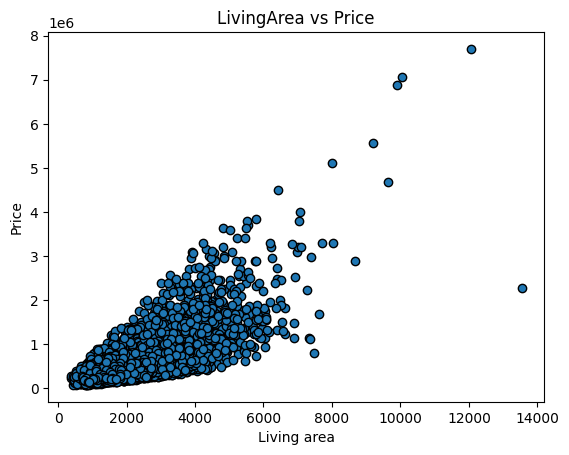

In [ ]:
plt.scatter(df['living area'], df['Price'],linewidths=1,edgecolors="black")
plt.xlabel("Living area")
plt.ylabel("Price")
plt.title("LivingArea vs Price")
plt.show()